> **🔑 Note:-** `Top-1 accuracy` means "accuracy for the top `softmax activation` value output by the model" (because `softmax ouputs` a value for every class, but `top-1 means` only the highest one is evaluated). Top-5 accuracy means "accuracy for the top 5 softmax activation values output by the model", in other words, did the true label appear in the `top 5 activation values` ? Top-5 accuracy scores are usually noticeably higher than `top-1`.

In [1]:
'''
                    🍔👁 Food Vision Big™	    🍔👁 Food Vision mini

Dataset source	    TensorFlow Datasets	        Preprocessed download from Kaggle.
Train data	        75,750 images	            7,575 images
Test data	        25,250 images	            25,250 images
Mixed precision	    Yes                         No
Data loading	    Performanant tf.data API	TensorFlow pre-built function
Target results	    77.4% top-1 accuracy        50.76% top-1 accuracy
                    (beat DeepFood paper)	    (beat Food101 paper).

# Table comparing difference between Food Vision Big (this notebook) versus Food Vision mini (previous notebook).
'''

'\n                    🍔👁 Food Vision Big™\t    🍔👁 Food Vision mini\n\nDataset source\t    TensorFlow Datasets\t        Preprocessed download from Kaggle.\nTrain data\t        75,750 images\t            7,575 images\nTest data\t        25,250 images\t            25,250 images\nMixed precision\t    Yes                         No\nData loading\t    Performanant tf.data API\tTensorFlow pre-built function\nTarget results\t    77.4% top-1 accuracy        50.76% top-1 accuracy\n                    (beat DeepFood paper)\t    (beat Food101 paper).\n\n# Table comparing difference between Food Vision Big (this notebook) versus Food Vision mini (previous notebook).\n'

### **Get helper functions.**

In [2]:
# Get helper functions file
import os

if not os.path.exists("helper_functions.py"):
    !wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
else:
    print("[INFO] 'helper_functions.py' already exists, skipping download.")

--2025-02-19 08:52:02--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2025-02-19 08:52:03 (74.2 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [3]:
# Import series of helper functions for the notebook (we've created/used these in previous notebooks)
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

Two methods that we are to going to significantly improve the `speed of our model training`:

* Prefetching.

* Mixed Precision Training.


### What we are going to cover:

* Using TensorFlow Datasets to download and explore data.

* Creating preprocessing function for our data.

* Batching & preparing datasets for modelling (making our datasets run fast).

* Creating modelling callbacks.

* Setting up `mixed precision training`.

* Building a feature extraction model.

* Fine-Tunning the feature extraction model.

* Viewing training results on TensorBoard.

### **What does mixed precision training do ?**

`Mixed precision training` uses a combination of `single precision (float32)` and `half-preicison (float16)` data types to speed up model training `(up 3x on modern GPUs)`.



In [4]:
# Get GPU name
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-0a8de644-a6af-1349-7c6e-65d31b2223cd)


In [5]:
# Install tf-nightly (required until 2.13.0+ is the default in Google Colab)
!pip install -U -q tf-nightly

# Check TensorFlow version (should be minimum 2.4.0+ but 2.13.0+ is better)
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

# Add timestamp
import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 646.9/646.9 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 58.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.1 which is incompatible.
TensorFlow version: 2.18.0
Notebook last run (end-to-end): 2025-02-19 08:53:17.440229


### **Use TensorFlow Datasets to Download Data.**

What is **TensorFlow Datasets** ?

Why use **TensorFlow Datasets** ?

* Load data already in Tensors.
* Practice on well established datasets.
* Experiment with differet data loading techniques (like we're going to use in this notebook).
* Experiment with new TensorFlow features quickly (such as mixed precision training).

Why not use **TensorFlow Datasets** ?

* The datasets are static (they don't change, like your real-world datasets would).
* Might not be suited for your particular problem (but great for experimenting).


In [6]:
# Get TensorFlow Datasets
import tensorflow_datasets as tfds

# Get all available datasets in TFDS.
datasets_list = tfds.list_builders()

# Set our target dataset and see if it exists.
target_dataset = "food101"
print(f"{target_dataset} in TensorFlow Datasets: {target_dataset in datasets_list}")

food101 in TensorFlow Datasets: True


In order to get an access to the `Food101` dataset from the TFDS, we can use the `tfds.load()` method.

* `name (str):` the target dataset (e.g., "food101").
* `split (list, optional):` what splits of the dataset we are after (e.g.,`["train", "validation"]`).
    * the `split` parameter is quite tricky.
* `shuffle_files (bool):` whether or not to shuffle the files on download, defaults to `False`.
* `as_supervised(bool):` `True` to download data samples in tuple format ((data, label)) or False for dictionary format.
* with_info(bool): True to download dataset metadata (labels, number of samples, etc).

> `Note:` Calling the `tfds.load()` method will start to download a target dataset to disk if the `download=True` parameter is set (default).

In [7]:
# Load in thge data (take about 5-6 minutes in Google Colab).
(train_data, test_data), ds_info = tfds.load(
    name="food101", # target dataset to get from TFDS.
    split=["train", "validation"], # what splits of data should we get ? Note: all datasets have train, valid, test.
    shuffle_files=True, # shuffle files on download ?
    as_supervised=True, # download data in tuple format (sample, label), # e.g., (image, label).
    with_info=True, # include dataset metadata ? if so, tfds.load() returns tuple (data, ds_info)
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/75750 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.NKLJ15_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...:   0%|          | 0/25250 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.NKLJ15_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


Getting class names from a TensorFlow Datasets dataset requires downloading the "dataset_info" variable (by using the `as_supervised=True` parameter in the `tfds.load()` method, **Note:-** this will only work for supervised datasets in TFDS).

In [8]:
# Getting an access of the class_names of a particular dataset using dataset_info.features attribute and accessing names attribute of the `label` key.

# Features of Food101 TFDS.
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [9]:
# Get class names.
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

### Exploring the Food101 data from TensorFlow Datasets:

Let's find out a few details about our dataset:

* The shape of our input data (image tensors).
* The datatype of our input data.
* What labels of our input data look like (e.g., one-hot-encoded versus label-encoded).
* Do the labels match up with the class names ?

To do, Let's take one sample off the training data (Using the .take() method) and explore it.

In [10]:
# Take one sample off the training data.
train_one_sample = train_data.take(1) # sample as in format (image_tensor, label)

Because we used the as_supervised=True parameter in our `tfds.load()` method above, data samples come in the tuple format structure (data, label) or in our case (image_tensor, label).

In [11]:
# what does one sample for our training data look like ?
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [12]:
# Output info about our training sample.
for image,label in train_one_sample:
    print(f"""
            Image shape: {image.shape}
            Image dtype: {image.dtype}
            Target class from Food101 (tensor form): {label}
            Class name (str form): {class_names[label.numpy()]}
        """)


            Image shape: (512, 512, 3)
            Image dtype: <dtype: 'uint8'>
            Target class from Food101 (tensor form): 21
            Class name (str form): chocolate_cake
        


Because we set the `shuffle_files=True` parameter in our `tfds.load()` method above, running the cell above a few times will give a different result each time.

In [13]:
# What does an image tensor from TFDS's Food101 look like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 32,  14,   0],
        [ 31,  13,   0],
        [ 28,  12,   0],
        ...,
        [ 54,  34,  10],
        [ 53,  33,   9],
        [ 51,  31,   7]],

       [[ 28,  10,   0],
        [ 28,  10,   0],
        [ 27,  11,   0],
        ...,
        [ 56,  36,  12],
        [ 55,  35,  11],
        [ 54,  34,   9]],

       [[ 30,  12,   0],
        [ 31,  13,   0],
        [ 31,  15,   0],
        ...,
        [ 58,  38,  13],
        [ 58,  38,  13],
        [ 58,  38,  11]],

       ...,

       [[135,  80,   0],
        [136,  81,   1],
        [137,  82,   2],
        ...,
        [ 13,   6,   0],
        [ 13,   6,   0],
        [ 13,   6,   0]],

       [[137,  82,   2],
        [137,  82,   2],
        [137,  82,   2],
        ...,
        [ 13,   6,   0],
        [ 13,   6,   0],
        [ 13,   6,   0]],

       [[136,  81,   1],
        [135,  80,   0],
        [135,  80,   0],
        ...,
        [ 14,   7,   

In [14]:
# What are the min and max values?
import tensorflow as tf

tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

### Plot an image from TensorFlow Datasets

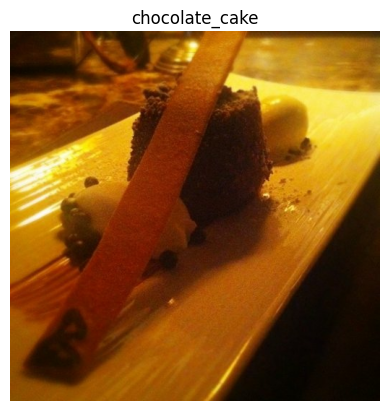

In [15]:
# Plot an image tensor.
import matplotlib.pyplot as plt

plt.imshow(image)
plt.title(class_names[label.numpy()]) # add title to image by indexing on class_names list.
plt.axis(False);

### **Create preprocessing functions for our data:**

When our images were in folder format we used the method `tf.keras.utils.image_dataset_from_directory()` to load them in.

Since, We've downloaded the data from TensorFlow Datasets, there are a couple of preprocessing steps we have to take before it's ready to model.

More specifically, our data is currently:

* In `uint8` data type.

* Comprised of all differnet sized tensors (different sized images).

* Not scaled (the pixel values are between 0 & 255).

Whereas, models like data to be:

* In float32 data type.

* Have all of the same size tensors (batches require all tensors have the same shape, e.g. (224, 224, 3)).

* Scaled (values between 0 & 1), also called `normalized`

To take care of these, we'll create a `preprocess_img()` function which:

* Resizes an input image tensor to a specified size using `tf.image.resize()`.

* Converts an input image tensor's current datatype to `tf.float32` using `tf.cast()`.

> **🔑 Note:-** Pretrained EfficientNetBX models in tf.keras.applications.efficientnet (what we're going to be using) have rescaling built-in. But for many other model architectures we'll want to rescale our data (e.g. get its values between 0 & 1). This could be incorporated inside our `"preprocess_img()"` function (like the one below) or within your model as a `tf.keras.layers.Rescaling` layer.


In [16]:
# Make a function for preprocessing images.
def preprocess_img(image, label, img_shape=224):
    """
    Converts image datatypes from "uint8" -> "float32" and reshapes image to [image_shape, image_shape, color_channels]
    """
    image = tf.image.resize(image, [img_shape, img_shape]) # reshape to image shape.
    return tf.cast(image, tf.float32), label # return (flat32_image, label) tuple.

# Our preprocess_img() function above takes image and label as input (even though it does nothing to the label) because our dataset is currently in the tuple structure (image, label).

# Preprocess a single sample image and check the outputs
preprocesed_img = preprocess_img(image, label)[0]

# Preprocess a single sample image and check the outputs
preprocessed_img = preprocess_img(image, label)[0]

print(f"Image before preprocessing:\n {image[:2]}...,\nShape: {image.shape},\nDatatype: {image.dtype}\n")
print(f"Image after preprocessing:\n {preprocessed_img[:2]}...,\nShape: {preprocessed_img.shape},\nDatatype: {preprocessed_img.dtype}")

Image before preprocessing:
 [[[32 14  0]
  [31 13  0]
  [28 12  0]
  ...
  [54 34 10]
  [53 33  9]
  [51 31  7]]

 [[28 10  0]
  [28 10  0]
  [27 11  0]
  ...
  [56 36 12]
  [55 35 11]
  [54 34  9]]]...,
Shape: (512, 512, 3),
Datatype: <dtype: 'uint8'>

Image after preprocessing:
 [[[29.19898    11.198979    0.        ]
  [28.285715   12.285714    0.        ]
  [30.852041   15.494898    0.28061217]
  ...
  [52.9336     32.505074    8.7193365 ]
  [54.025528   34.025528   10.025528  ]
  [53.800972   33.800972    9.571359  ]]

 [[33.09694    15.096939    1.193878  ]
  [33.785713   17.785715    2.785715  ]
  [31.785713   16.428572    1.2142859 ]
  ...
  [63.60206    42.530632   15.346998  ]
  [61.647934   40.7857     13.928558  ]
  [60.785713   41.714287   12.020403  ]]]...,
Shape: (224, 224, 3),
Datatype: <dtype: 'float32'>


> The input image gets converted from `uint8` to `float32` and gets reshaped from its current shape to `(224, 224, 3)`.

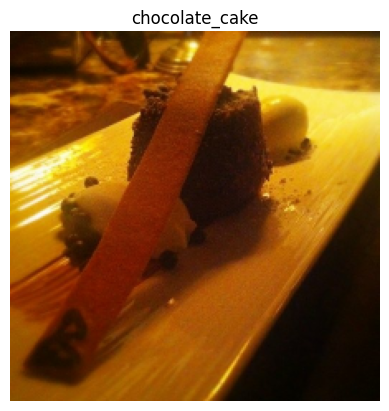

In [17]:
# we can still plot our preprocessed image as long as we.
# divide by 255 (for matplotlib capatibility).

plt.imshow(preprocessed_img/255.)
plt.title(class_names[label])
plt.axis(False);

### Batch & prepare datasets:

Before we can model our data, we have to turn it into batches.

>  Why ? Because **computing on batches is memory efficient.**



Specifically, We're going to be using:

* **`map()`** - maps a predefined function to a target dataset (e.g. **`preprocess_img()`** to our image tensors)

* **`shuffle()`** - randomly shuffles the elements of a target dataset up **`buffer_size`** (ideally, the **`buffer_size`** is equal to the size of the dataset, however, this may have implications on memory).

* **`batch()`** - turns elements of a target dataset into batches (size defined by parameter **`batch_size`**).

* **`prefetch()`** - prepares subsequent batches of data whilst other batches of data are being computed on (improves data loading speed but costs memory).

* **Extra: `cache()`** - caches (saves them for later) elements in a target dataset, saving loading time (will only work if your dataset is small enough to fit in memory, standard Colab instances only have 12GB of memory)

Things to note:

* Can't batch tensors of different shapes (e.g. different image sizes, need to reshape images first, hence our **`preprocess_img()`** function)

* **`shuffle()`** keeps a buffer of the number you pass it images shuffled, ideally this number would be all of the samples in your training set, however, if your training set is large, this buffer might not fit in memory (a fairly large number like 1000 or 10000 is usually suffice for shuffling)

* For methods with the num_parallel_calls parameter available (such as **`map()`**), setting it to **`num_parallel_calls=tf.data.AUTOTUNE`** will parallelize preprocessing and significantly improve speed

* Can't use **`cache()`** unless your dataset can fit in memory

    Original dataset (e.g. train_data) -> map() -> shuffle() -> batch() -> prefetch() -> PrefetchDataset


> "Hey, map this **`preprocessing`** function across our **training** dataset, then **shuffle** a number of elements before **batching** them together and make sure you prepare new **batches** (**`prefetch`**) whilst the **model** is looking through the **`current batch`**".

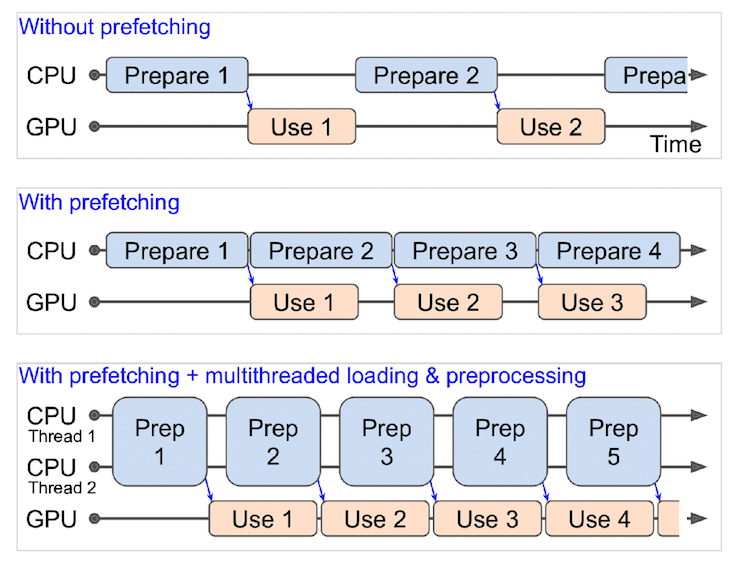

In [18]:
# What happens when you use prefetching (faster) versus what happens when you don't use prefetching (slower).

In [19]:
# Map preprocessing function to training data (and paralellize).
train_data = train_data.map(
    map_func=preprocess_img,
    num_parallel_calls=tf.data.AUTOTUNE
)

# shuffle train_data and turn it into batches and prefetch it (load it faster).
train_data = train_data.shuffle(
    buffer_size=1000
).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

# Map Preprocessing function to test data.
test_data = test_data.map(
    preprocess_img,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Turn test data into batches (don't need to shuffle).
test_data = test_data.batch(32).prefetch(tf.data.AUTOTUNE)

In [20]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

**Data Format:-** `(Image, Label)` ------> **DataTypes:-** `(tf.float32, tf.int64)`

### **Create modelling callbacks:**

`Callbacks` is object that can be used to performs actions at various stages of training (e.g., at the start or end of an epoch, before or after a single batch, etc).

we can use callbacks to:

* Write TensorBoard Logs after every batch of training to monitor metrics.

* Periodically save our model to disk.

* To Perform early stopping.

* Get a view on internal states and statistics of a model during training.


    my_callbacks = [
        keras.callbacks.EarlyStopping(patience=2),
        keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.h5'),
        keras.callbacks.TensorBoard(log_dir='./logs'),
    ]
    model.fit(dataset, epochs=10, callbacks=my_callbacks)

To implements the callbacks we are using the following callbacks:

* `tf.keras.callbacks.TensorBoard():-` Allows us to keep track of our model's training history so we can inspect it later.

* `tf.keras.callbacks.ModelCheckpoint():-` saves our model's progress at various intervals so we can load it and re-use it later without having to retrain it.

    *  Checking pointing is also helpful so we can start fine-tunning our model at a particular epoch and revert back to a previous state if fine-tunning offers no benefits.

In [21]:
# Create TensorBoard callback (already have "create_tensorboard_callback()" from a previous notebook)
from helper_functions import create_tensorboard_callback

# Create ModelCheckpoint callback to save model's progress
checkpoint_path = "model_checkpoints/.weights.h5" # saving weights requires ".ckpt" extension
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy", # save the model weights with best validation accuracy
    save_best_only=True, # only save the best weights
    save_weights_only=True, # only save model weights (not whole model)
    verbose=0) # don't print out whether or not model is being saved

### **Setup mixed precision training.**

 `Float32` is also known as `single-precision floating-point` format. The `32 means` it usually occupies `32 bits` in `computer memory`.

 Our GPU has a limited memory, therefore it can only handle a number of float32 tensors at the same time.

This is where mixed precision training comes in.

Mixed precision training involves using a mix of float16 and float32 tensors to make better use of your GPU's memory.

 **`float32`** meant **`single-precision floating-point`**, and **`float16`** means **`half-precision floating-point`** format


As mentioned before, when using mixed precision training, your model will make use of float32 and float16 data types to use less memory where possible and in turn run faster (using less memory per tensor means more tensors can be computed on simultaneously).


As a result, using mixed precision training can improve your performance on modern GPUs (those with a compute capability score of 7.0+) by up to 3x.

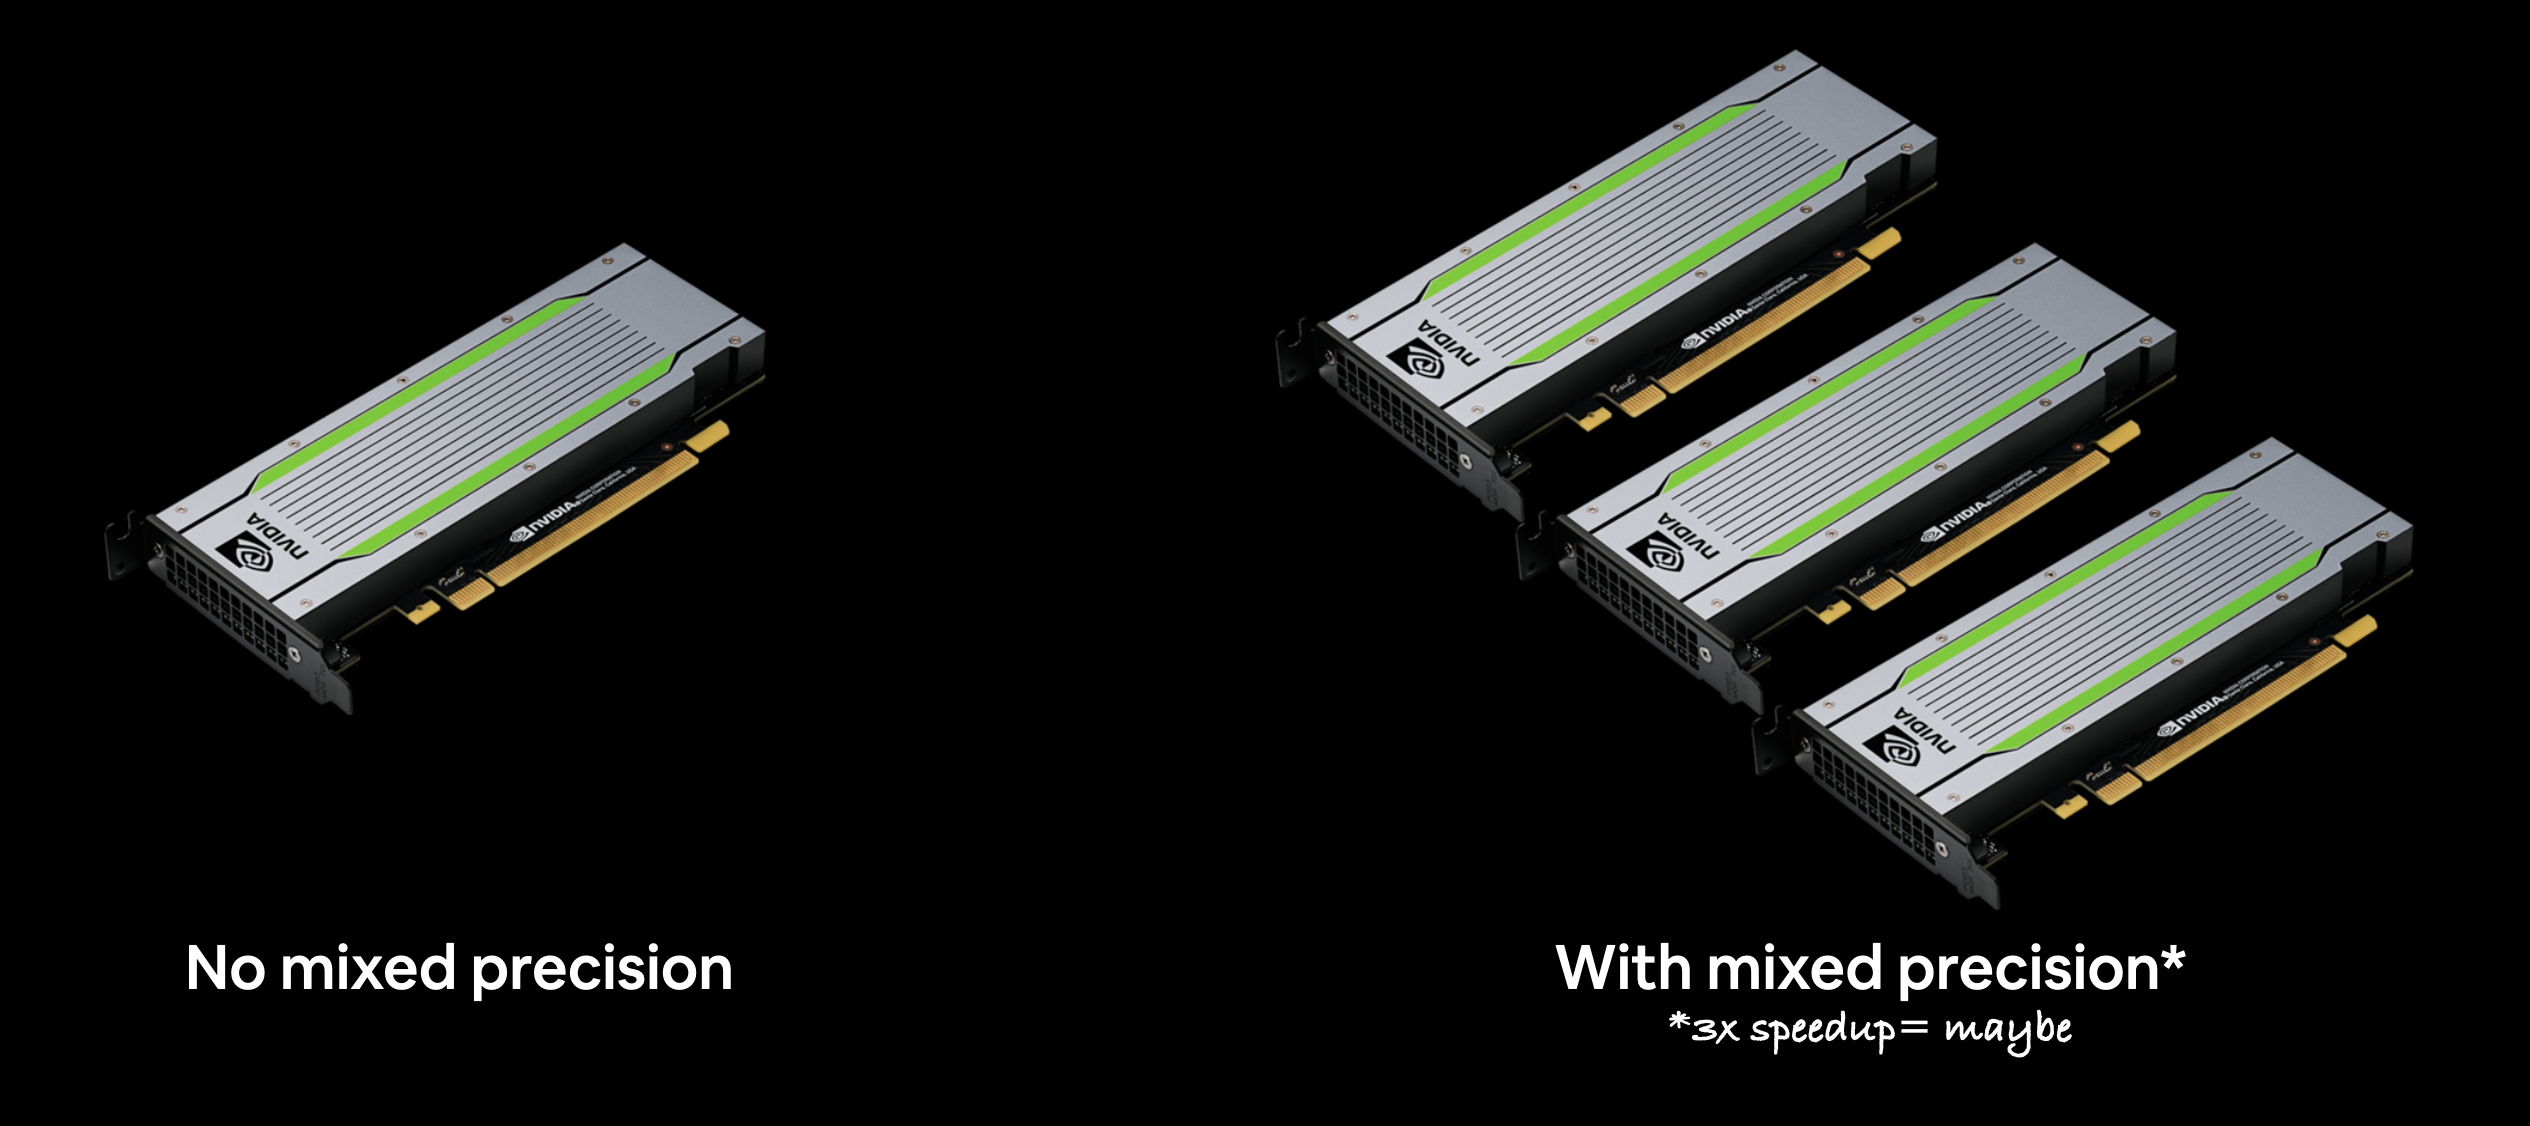

Because mixed precision training uses a combination of float32 and float16 data types, you may see up to a 3x speedup on modern GPUs.

In [22]:
# Turn on Mixed precision training.
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy(policy="mixed_float16") # set global policy to mixed precision.

In [23]:
mixed_precision.global_policy() # should output "mixed_float16" (if your GPU is compatible with mixed precision)

<DTypePolicy "mixed_float16">

### **Build feature extraction model:**

The typical order for using `transfer learning` is:

1. Build a **feature extraction model** (replace the top few layers of a pretrained model).

2. **Train** for a few epochs with **lower layers frozen**.

3. **Fine-tune** if necessary with multiple layers unfrozen.

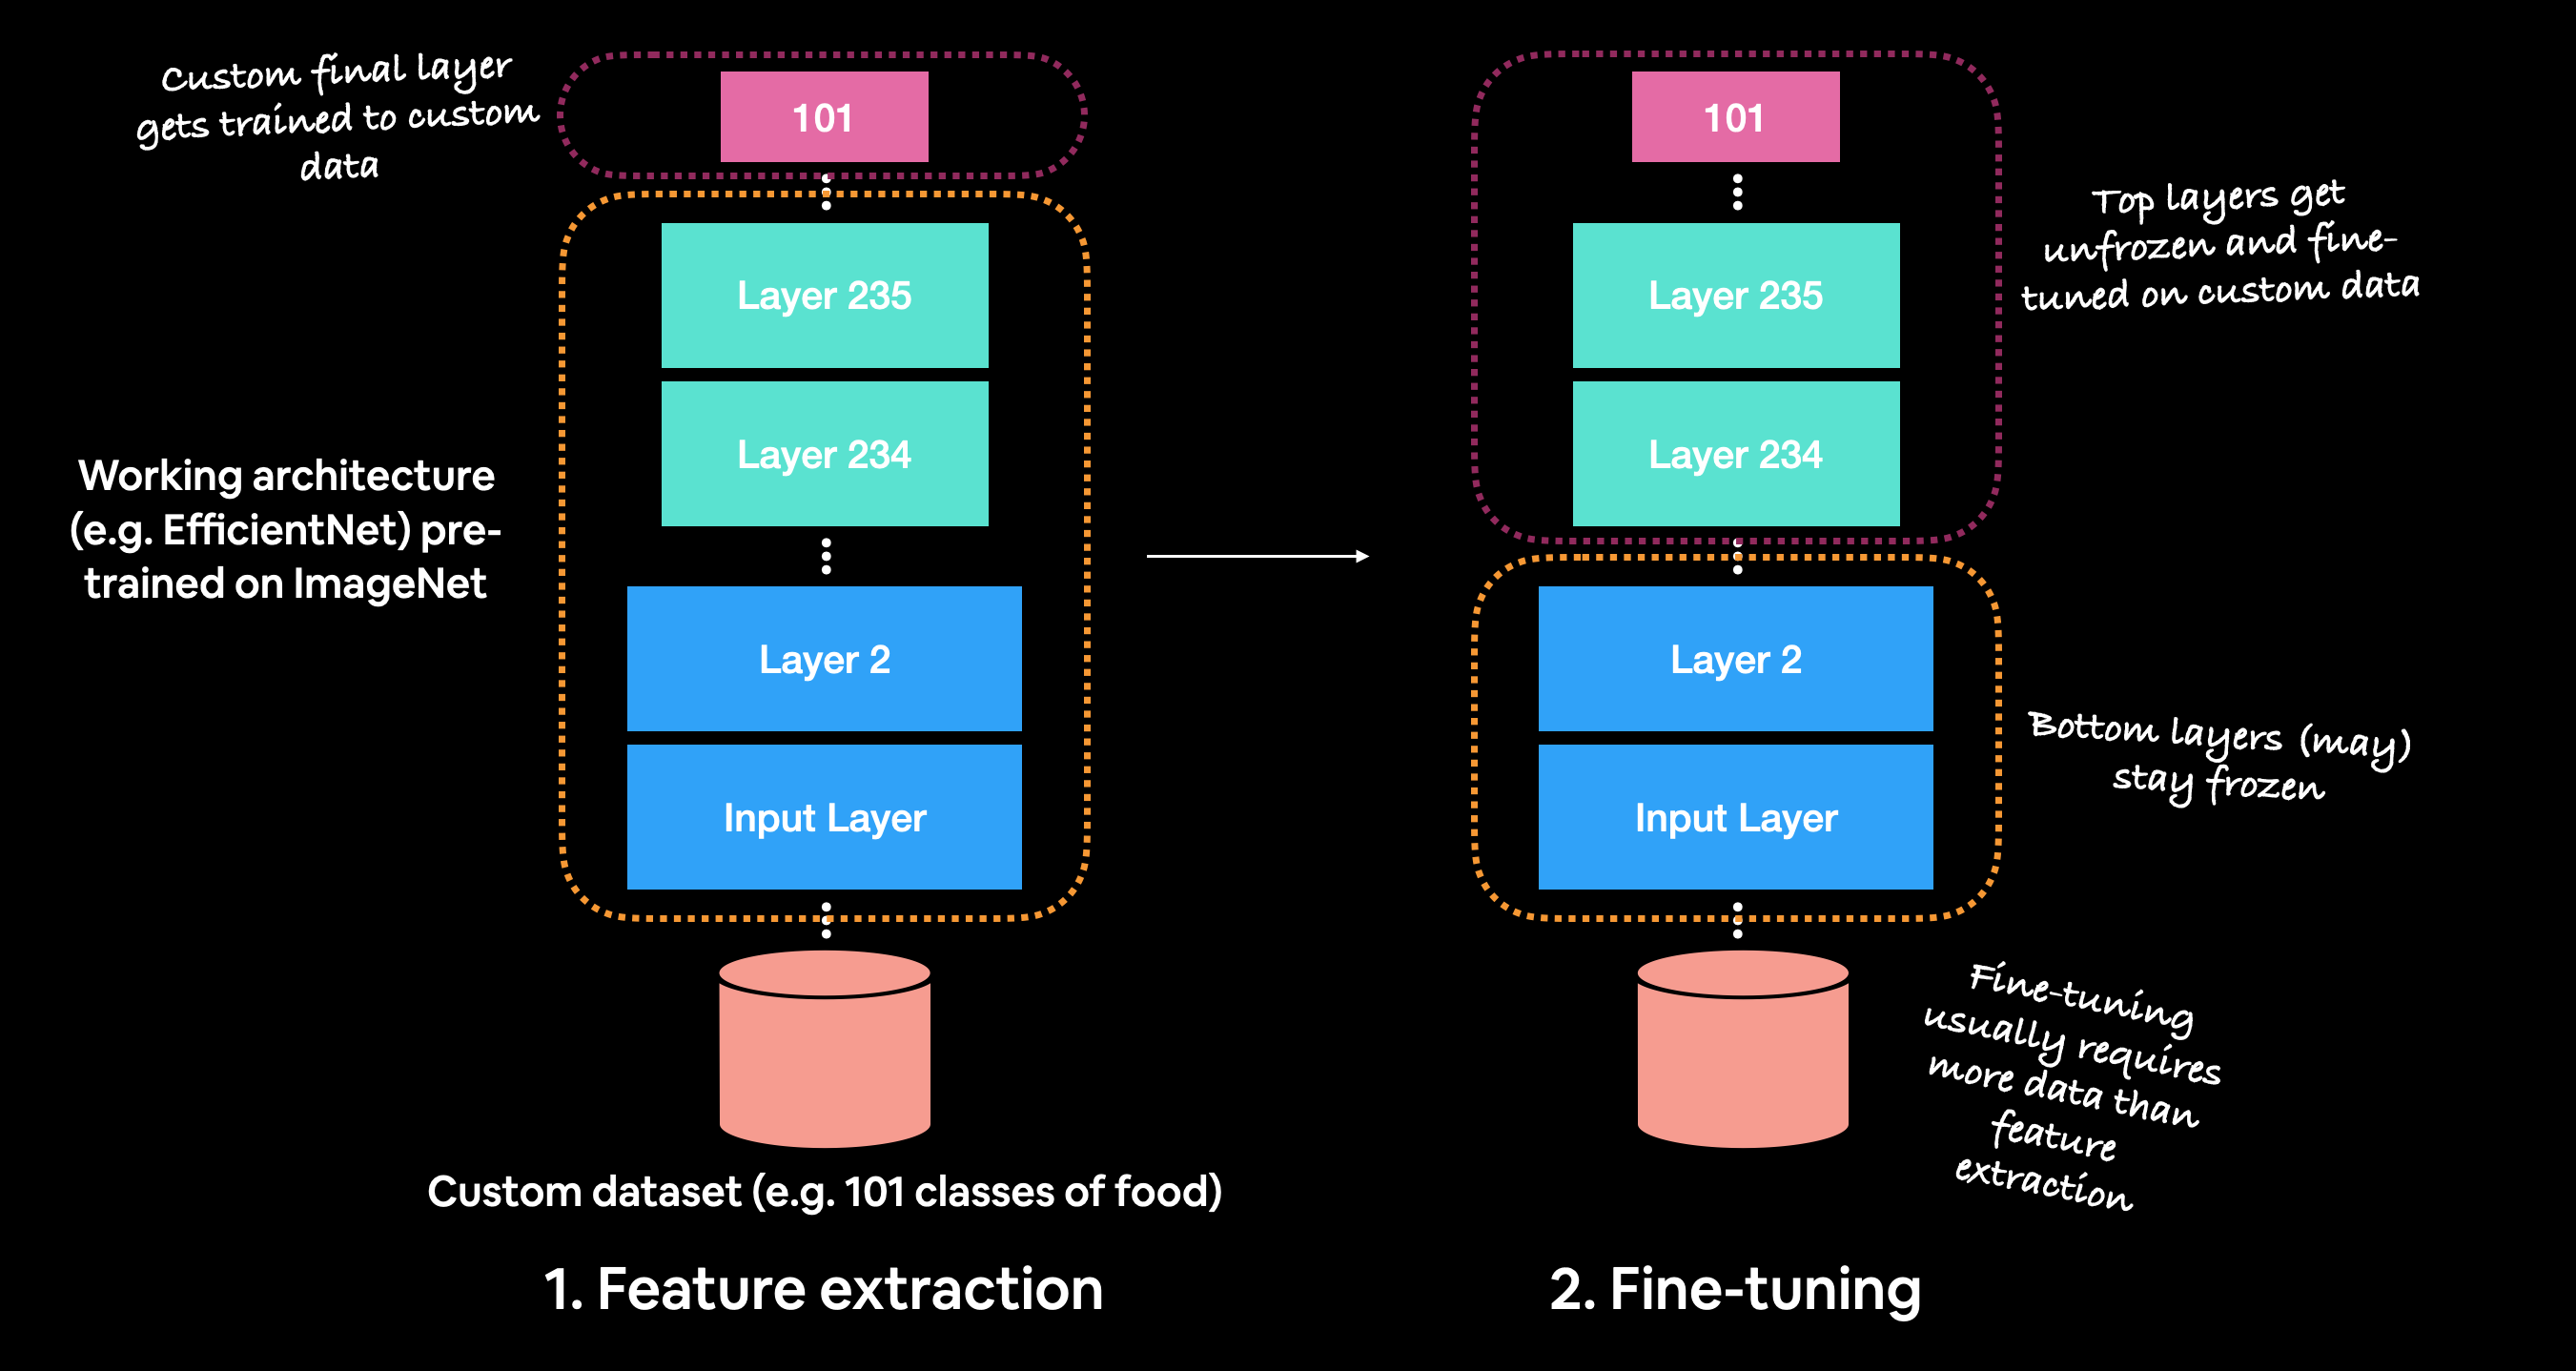

Before fine-tuning, it's best practice to train a feature extraction model with custom top layers.

To build the **feature extraction model**:

* Use `EfficientNetB0` from `tf.keras.applications` pre-trained on `ImageNet` as our base model
    
    * We'll download this without the top layers using `include_top=False` parameter so we can create our own output layers.

* Freeze the base model layers so we can use the pre-learned patterns the base model has found on ImageNet.

* Put together the input, base model, pooling and output layers in a Functional model.

* Compile the Functional model using the Adam optimizer and sparse categorical crossentropy as the loss function (since our labels **`aren't`** one-hot encoded).

* Fit the model for 3 epochs using the TensorBoard and ModelCheckpoint callbacks


> **`🔑 Note:-`** Since, We're using mixed precision training, our model needs a separate output layer with a hard-coded **dtype=float32**, for example, layers.**Activation("softmax", dtype=tf.float32)**. This ensures the outputs of our model are returned back to the float32 data type which is more numerically stable than the float16 datatype (important for loss calculations). See the "Building the model" section in the TensorFlow mixed precision guide for more.


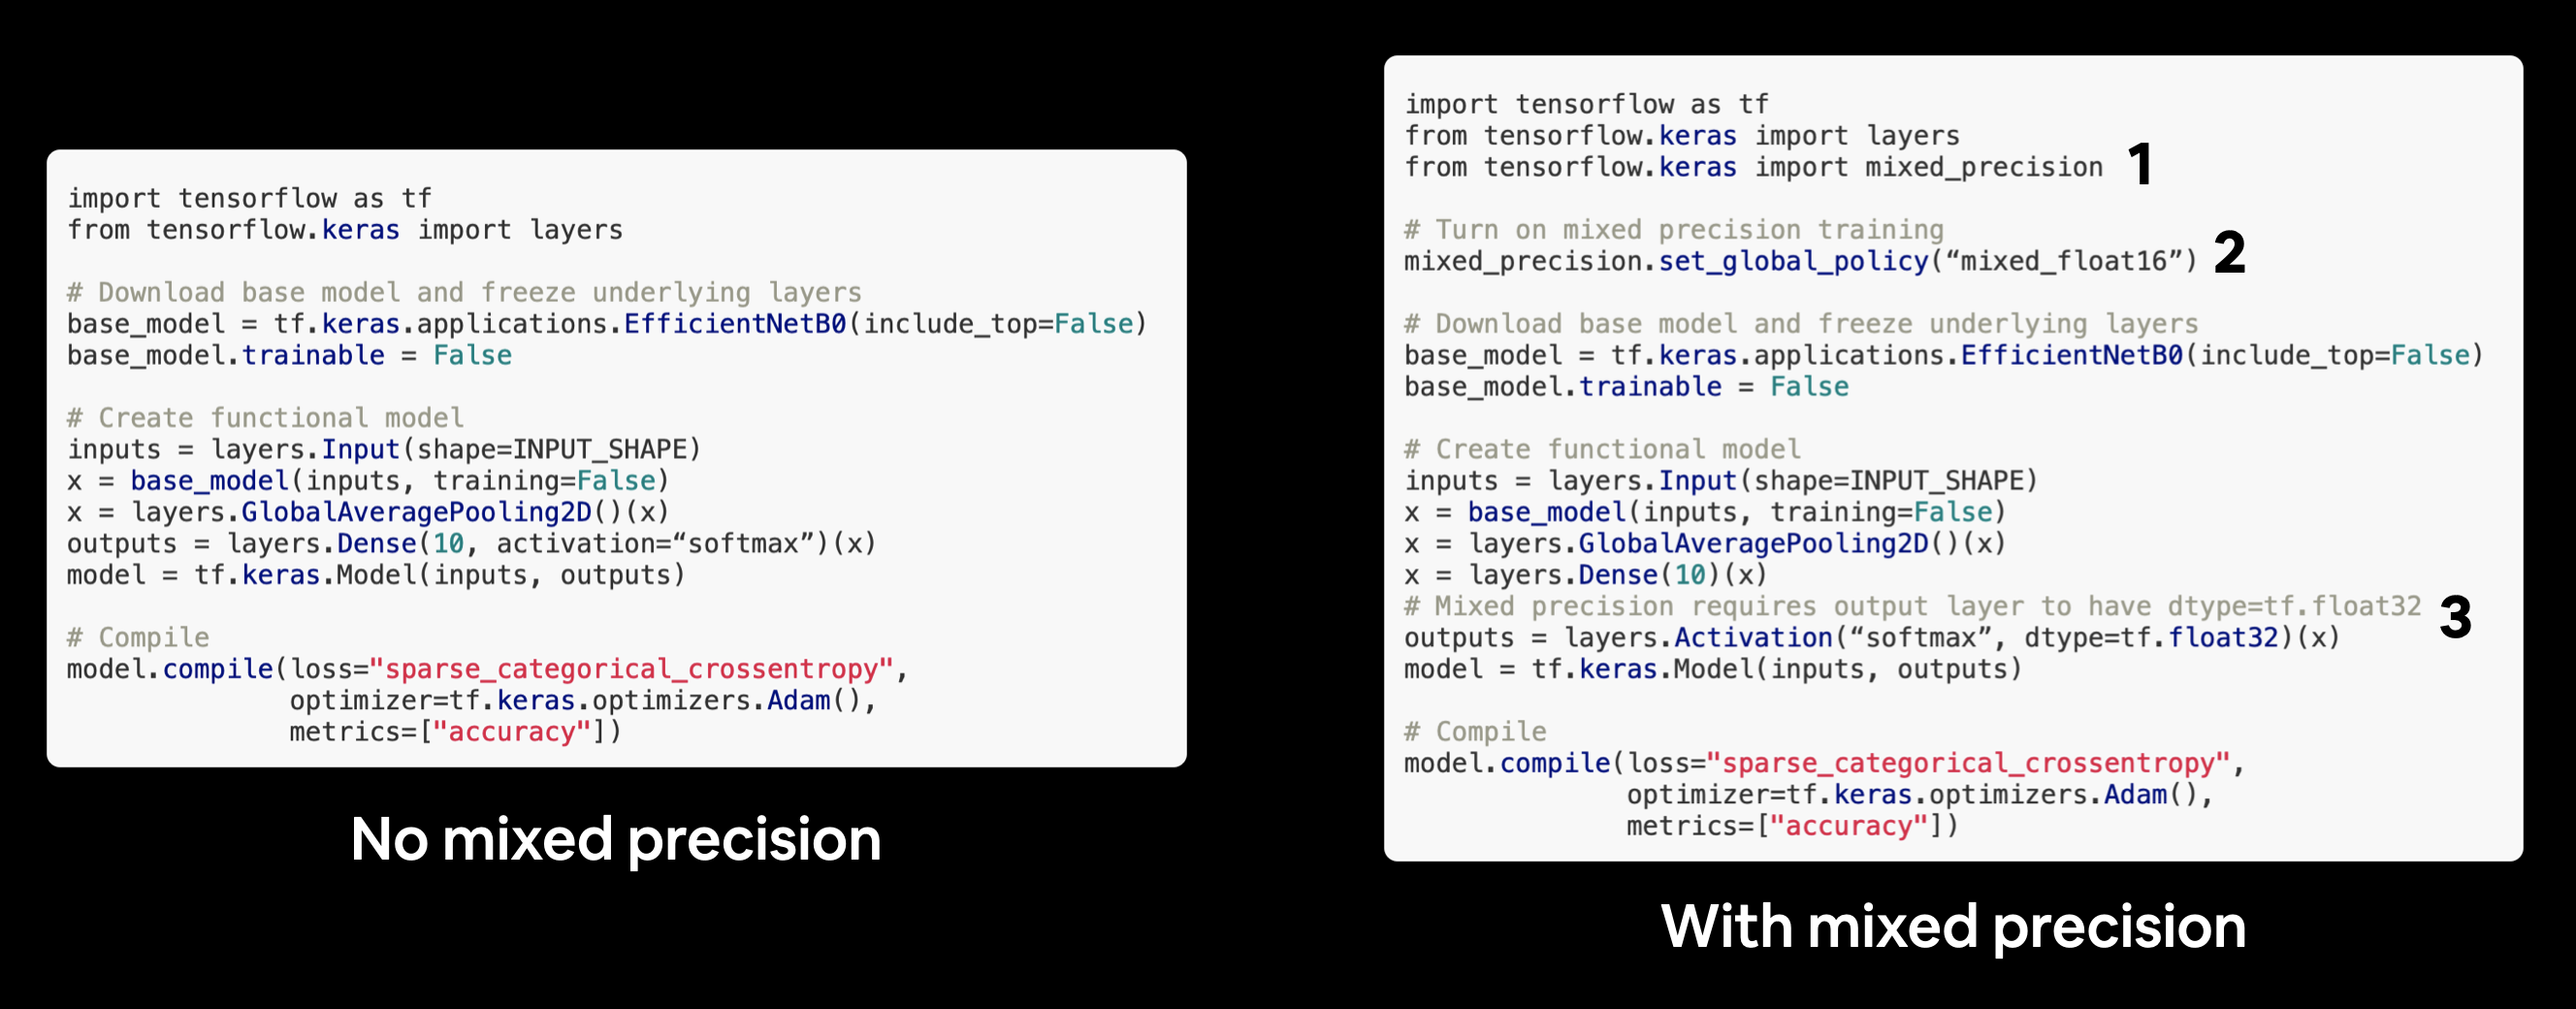

Turning mixed precision on in TensorFlow with 3 lines of code.

In [24]:
from tensorflow.keras import layers
import tensorflow as tf

# Create base model.
input_shape = (224, 224, 3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False # freeze base model layers.

# Create Functional Model.
inputs = layers.Input(
    shape=input_shape,
    name="input_layer"
)

# In EfficientNetBX models have rescaling built-in.
x = base_model(inputs, training=False) # set base_model to inference mode only.
x = layers.GlobalAveragePooling2D(name="pooling_layer")(x)
x = layers.Dense(len(class_names))(x) # want one output neuron per class.

# Separate activation of output layer so we can output float32 activations.
outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)
model = tf.keras.Model(inputs, outputs)

# Compile the Model.
model.compile(
    loss="sparse_categorical_crossentropy", # use sparse_categorical_crossentropy when labels are not one hot.
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [25]:
# Checking model summary.
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pooling_layer                        │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 101)                 │         129,381 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ cast_1 (Cast)                        │ (None, 101)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_float32 (Activation)         │ (None, 101)                 │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### **Checking layer dtype policies (are we using mixed precision?)**

In [26]:
# Check the dtype_policy attributes of layers in our model.
for layer in model.layers:
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy) # Check the dtype policy of layers.

input_layer True float32 <DTypePolicy "mixed_float16">
efficientnetb0 False float32 <DTypePolicy "mixed_float16">
pooling_layer True float32 <DTypePolicy "mixed_float16">
dense True float32 <DTypePolicy "mixed_float16">
softmax_float32 True float32 <DTypePolicy "float32">


* **`layer.name (str):`** a layer's human-readable name, can be defined by the name parameter on construction.

* **`layer.trainable (bool):`** whether or not a layer is trainable (all of our layers are trainable except the efficientnetb0 layer since we set it's trainable attribute to False.

* **`layer.dtype:`** the data type a layer stores its variables in.

* **`layer.dtype_policy:`** the data type a layer computes in.


> `🔑 Note:-` A layer can have a dtype of **float32** and a dtype policy of **"mixed_float16"** because it stores its **variables** (**weights** & **biases**) in **float32** (more numerically stable), however it computes in **float16** (**faster**).

In [27]:
# Check the layers in the base model and see what dtype policy they're using
for layer in model.layers[1].layers[:20]: # only check the first 20 layers to save output space
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer False float32 <DTypePolicy "mixed_float16">
rescaling False float32 <DTypePolicy "mixed_float16">
normalization False float32 <DTypePolicy "mixed_float16">
rescaling_1 False float32 <DTypePolicy "mixed_float16">
stem_conv_pad False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_dwconv False float32 <DTypePolicy "mixed_float16">
block1a_bn False float32 <DTypePolicy "mixed_float16">
block1a_activation False float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze False float32 <DTypePolicy "mixed_float16">
block1a_se_reshape False float32 <DTypePolicy "mixed_float16">
block1a_se_reduce False float32 <DTypePolicy "mixed_float16">
block1a_se_expand False float32 <DTypePolicy "mixed_float16">
block1a_se_excite False float32 <DTypePolicy "mixed_float16">
block1a_project_conv False float32 <DTypePolicy "mixed_float16"

### **Fit the feature extraction model.**

In [28]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [29]:
# Turn off all warnings except for errors
tf.get_logger().setLevel('ERROR')

# Fit the model with callbacks.
history_101_food_classes_feature_extract = model.fit(train_data,
    epochs=3,
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)),
    callbacks=[create_tensorboard_callback("training_logs",   "efficientnetb0_101_classes_all_data_feature_extract"),
    model_checkpoint]
)

Saving TensorBoard log files to: training_logs/efficientnetb0_101_classes_all_data_feature_extract/20250219-090307
Epoch 1/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 246s 89ms/step - accuracy: 0.4752 - loss: 2.2857 - val_accuracy: 0.6976 - val_loss: 1.1448
Epoch 2/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 255s 93ms/step - accuracy: 0.6679 - loss: 1.2925 - val_accuracy: 0.7188 - val_loss: 1.0294
Epoch 3/3
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 201s 84ms/step - accuracy: 0.7059 - loss: 1.1242 - val_accuracy: 0.7206 - val_loss: 1.0003


In [33]:
# Evaluate model (unsaved version) on what test dataset.
results_feature_extract_model = model.evaluate(test_data)
results_feature_extract_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 54s 68ms/step - accuracy: 0.7235 - loss: 1.0054


[0.9999656081199646, 0.7293069362640381]

### **Load and evaluate checkpoint weights.**

We can load in and evaluate our model's checkpoints by:

1. Recreating a new instance of our model called **created_model** by turning our original model creation code into a function called **create_mode()**.

2. Compiling our **`created_model`** with the same loss, optimizer, and metrics as the original model (every time we create a new model, we have to compile it).

3. Calling the **`load_weights()`** method on our created_model and passing it the path to where our checkpointed weights are stored.

4. Calling **`evaluate()`** on **`created_model`** with loaded weights and saving the results.

5. Comparing the **`created_model`** results to our previous **`model`** results (these should be the exact same, if not very close).


In [35]:
# 1. Create a function to recreate the original model.
def create_model():
    # create base model.
    input_shape = (224, 224, 3)
    base_model = tf.keras.applications.efficientnet.EfficientNetB0(include_top=False)
    base_model.trainable = False # freeze base model layers.

    # Create Functional model.
    inputs = layers.Input(shape=input_shape, name="input_layer")
    x = base_model(inputs, training=False) # set base_model to inference mode only.
    x = layers.GlobalAveragePooling2D(name="pooling_layer")(x)
    x = layers.Dense(len(class_names))(x) # want one output neuron per class.
    # separate activation of output layer so we can output float32 activations.
    outputs = layers.Activation("softmax", dtype=tf.float32, name="softmax_float32")(x)
    model = tf.keras.Model(inputs, outputs)

    return model

# 2. Create and compile a new version of the original model (new weights).
created_model = create_model()
created_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# 3. Load the saved weights.
created_model.load_weights(checkpoint_path)

# Evaluate the model with loaded weights.
results_created_model_with_loaded_weights = created_model.evaluate(test_data)

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 4 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


790/790 ━━━━━━━━━━━━━━━━━━━━ 61s 62ms/step - accuracy: 0.7242 - loss: 1.0053


Our **created_model** with loaded weight's results should be very close to the feature extraction model's results.

In [36]:
# 5. Loaded checkpoint weights should return very similar results to checkpoint weights prior to saving.
import numpy as np

assert np.isclose(results_feature_extract_model, results_created_model_with_loaded_weights).all(), "Loaded weights results are not close to original model." # check if all elements in array are close

Cloning the model preserves **dtype_policy's** of layers (but doesn't preserve weights) so if we wanted to continue fine-tuning our **created_model**, we could and it would still use the mixed precision dtype policy.

In [37]:
# Check the layers in the base model and see what dtype policy they are using.
for layer in created_model.layers[1].layers[:20]: # chekc only the first 20 layers to save printing space.
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer_1 False float32 <DTypePolicy "mixed_float16">
rescaling_2 False float32 <DTypePolicy "mixed_float16">
normalization_1 False float32 <DTypePolicy "mixed_float16">
rescaling_3 False float32 <DTypePolicy "mixed_float16">
stem_conv_pad False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_dwconv False float32 <DTypePolicy "mixed_float16">
block1a_bn False float32 <DTypePolicy "mixed_float16">
block1a_activation False float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze False float32 <DTypePolicy "mixed_float16">
block1a_se_reshape False float32 <DTypePolicy "mixed_float16">
block1a_se_reduce False float32 <DTypePolicy "mixed_float16">
block1a_se_expand False float32 <DTypePolicy "mixed_float16">
block1a_se_excite False float32 <DTypePolicy "mixed_float16">
block1a_project_conv False float32 <DTypePolicy "mixed_fl

### **Save the whole model to file.**

In [47]:
# We can also save the model using the save() method.

# Save model locally (if you're using Google Colab, your saved model will Colab instance terminates).
save_dir = "07_efficientnetb0_feature_extract_model_mixed_precision.keras"

# os.makedirs(save_dir) # Make directory if it does not exist.

# Save model.
model.save(save_dir)

In [48]:
# Load model previously saved above.
loaded_save_model = tf.keras.models.load_model(save_dir)

In [50]:
# Loading a SavedModel also retains all of the underlying layers dtype_policy (we want them to be "mixed_float16").
for layer in loaded_save_model.layers[1].layers[:20]: # check only the first 20 layers to save output space
    print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer True float32 <DTypePolicy "mixed_float16">
rescaling False float32 <DTypePolicy "mixed_float16">
normalization False float32 <DTypePolicy "mixed_float16">
rescaling_1 False float32 <DTypePolicy "mixed_float16">
stem_conv_pad False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_dwconv False float32 <DTypePolicy "mixed_float16">
block1a_bn False float32 <DTypePolicy "mixed_float16">
block1a_activation False float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze False float32 <DTypePolicy "mixed_float16">
block1a_se_reshape False float32 <DTypePolicy "mixed_float16">
block1a_se_reduce False float32 <DTypePolicy "mixed_float16">
block1a_se_expand False float32 <DTypePolicy "mixed_float16">
block1a_se_excite False float32 <DTypePolicy "mixed_float16">
block1a_project_conv False float32 <DTypePolicy "mixed_float16">

In [51]:
# Check loaded model performance (this should be the same as results_feature_extract_model)
results_loaded_saved_model = loaded_save_model.evaluate(test_data)
results_loaded_saved_model

790/790 ━━━━━━━━━━━━━━━━━━━━ 63s 64ms/step - accuracy: 0.7237 - loss: 1.0060


[0.9999649524688721, 0.7293069362640381]

In [52]:
# The loaded model's results should equal (or at least be very close) to the model's results prior to saving
# Note: this will only work if you've instatiated results variables
import numpy as np
assert np.isclose(results_feature_extract_model, results_loaded_saved_model).all()

### **Preparing our model's layers for fine-tuning.**

> **🔑 Note:-** It's worth remembering a traditional workflow for fine-tuning is to freeze a pre-trained base model and then train only the output layers for a few iterations so their weights can be updated inline with your custom data (feature extraction). And then unfreeze a number or all of the layers in the base model and continue training until the model stops improving.

In [53]:
# Download the saved model from Google Storage
!wget https://storage.googleapis.com/ztm_tf_course/food_vision/07_efficientnetb0_feature_extract_model_mixed_precision.zip

--2025-02-19 09:24:20--  https://storage.googleapis.com/ztm_tf_course/food_vision/07_efficientnetb0_feature_extract_model_mixed_precision.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 108.177.96.207, 108.177.119.207, 108.177.127.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|108.177.96.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16976857 (16M) [application/zip]
Saving to: ‘07_efficientnetb0_feature_extract_model_mixed_precision.zip’

07_efficientnetb0_f 100%[===================>]  16.19M  14.2MB/s    in 1.1s    

2025-02-19 09:24:22 (14.2 MB/s) - ‘07_efficientnetb0_feature_extract_model_mixed_precision.zip’ saved [16976857/16976857]



In [54]:
# Unzip the SavedModel downloaded from Google Stroage
!mkdir downloaded_gs_model # create new dir to store downloaded feature extraction model
!unzip 07_efficientnetb0_feature_extract_model_mixed_precision.zip -d downloaded_gs_model

Archive:  07_efficientnetb0_feature_extract_model_mixed_precision.zip
   creating: downloaded_gs_model/07_efficientnetb0_feature_extract_model_mixed_precision/
   creating: downloaded_gs_model/07_efficientnetb0_feature_extract_model_mixed_precision/variables/
  inflating: downloaded_gs_model/07_efficientnetb0_feature_extract_model_mixed_precision/variables/variables.data-00000-of-00001  
  inflating: downloaded_gs_model/07_efficientnetb0_feature_extract_model_mixed_precision/variables/variables.index  
  inflating: downloaded_gs_model/07_efficientnetb0_feature_extract_model_mixed_precision/saved_model.pb  
   creating: downloaded_gs_model/07_efficientnetb0_feature_extract_model_mixed_precision/assets/


In [64]:
# Load and evaluate downloaded GS model
loaded_gs_model = tf.keras.models.load_model("/content/07_efficientnetb0_feature_extract_model_mixed_precision.keras")

In [65]:
# Get a summary of our downloaded model
loaded_gs_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetb0 (Functional)          │ (None, 7, 7, 1280)          │       4,049,571 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ pooling_layer                        │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 101)                 │         129,381 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ cast_7 (Cast)                        │ (None, 101)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_float32 (Activation)         │ (None, 101)                 │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,437,720 (16.93 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 258,768 (1010.82 KB)

### **A Couple More Callbacks.**

The **`EarlyStopping`** is a callback that monitors a specified model performance metrics (e.g., **val_loss**) and when it stop improving for a specified number of epochs, it automatically stops training.

Using the **`EarlyStopping`** callback combined with the **`ModelCheckpoint`** callback saving the best performing model automatically, we could keep our model training for an unlimited number of epochs until it stops improving.

In [66]:
# Setup EarlyStopping callbacks to stop training if model's val_loss does not improve for 3 epochs.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", # watch the val loss metric.
    patience=3) # if val loss decreases for 3 epochs in a row, stop training.

# Create ModelCheckpoint callback to save best model during fine-tunning.
checkpoint_path = "/content/model_checkpoints/checkpoints.keras"
model_checkpoints = tf.keras.callbacks.ModelCheckpoint(
    checkpoint_path,
    save_best_only=True,
    monitor="val_loss"
)

**ReduceLROnPlateau:-** Helps to tune the learning rate.

**ModelCheckpoint** & **EarlyStopping**, **ReduceLROnPlateau** callback **monitors** a specified metrics and when that metrics stops improving, it reduces the **learning rate** by a specified factor (e.g., divided the learning rate by 10).

> 🤔 **Question:-** Why lower the **learning rate** ?

**Note:-** To monitor the validation loss just like the **EarlyStopping**, ReduceLROnPlateau can be used.


Once the **validation loss** stops improving for two or more epochs, we'll reduce the learning rate by a factor of 5 (e.g. 0.001 to 0.0002). And to make sure the learning rate doesn't get too low (and potentially result in our model learning nothing), we'll set the minimum **learning rate** to **1e-7**.

In [67]:
# Creating learning rate reduction callback.
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factror=0.2, # multiply the learning rate by 0.2 (reduce by 5x)
    patience=2,
    verbose=1, # print out when learning rate goes down.
    min_lr=1e-7
)

**Cross entropy loss:-** takes the target labels as One Hot Encoded Vectors, and this may not be feasible if we have may target classes, it is more efficient to represent the target labels as integers rather than one-hot encoded vectors and hence this is where Sparse Cross entropy should be used.

**sparse cross entropy loss:** used when our classes are mutually exclusive mean when one sample belongs to only one class, whiel cross entropy should be used when one sample can have multiple classes or labels or soft probabilities like [0.2, 0.7, 0.1]

In [68]:
# Compile the model.

loaded_gs_model.compile(loss="sparse_categorical_crossentropy", # sparse_categorical_crossentropy for labels that are *not* one-hot encoded.
                        optimizer=tf.keras.optimizers.Adam(0.0001),
                        metrics=["accuracy"])

In [71]:
# Start to fine-tune (all layers).
history_101_food_classes_all_data_fine_tune = loaded_gs_model.fit(
    train_data,
    epochs=100, # fine-tune for a maximum of 100 epochs.
    steps_per_epoch=len(train_data),
    validation_data=test_data,
    validation_steps=int(0.15 * len(test_data)), # validation during training on 15% of test data.
    callbacks = [
        create_tensorboard_callback(
            "training_logs", "efficientb0_101_classes_all_data_fine_tunning"
        ), # track the model training logs.
        model_checkpoints, # save only the best model during training.
        early_stopping, # stop model after X epochs of no improvements.
        reduce_lr # reduce the learning rate after X epochs of no improvements.
    ]
)

Saving TensorBoard log files to: training_logs/efficientb0_101_classes_all_data_fine_tunning/20250219-101919
Epoch 1/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 204s 75ms/step - accuracy: 0.7428 - loss: 0.9883 - val_accuracy: 0.7386 - val_loss: 0.9581 - learning_rate: 1.0000e-04
Epoch 2/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 171s 71ms/step - accuracy: 0.7478 - loss: 0.9719 - val_accuracy: 0.7394 - val_loss: 0.9493 - learning_rate: 1.0000e-04
Epoch 3/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 163s 68ms/step - accuracy: 0.7504 - loss: 0.9662 - val_accuracy: 0.7381 - val_loss: 0.9587 - learning_rate: 1.0000e-04
Epoch 4/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 202s 67ms/step - accuracy: 0.7528 - loss: 0.9508 - val_accuracy: 0.7423 - val_loss: 0.9441 - learning_rate: 1.0000e-04
Epoch 5/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 198s 66ms/step - accuracy: 0.7583 - loss: 0.9348 - val_accuracy: 0.7431 - val_loss: 0.9394 - learning_rate: 1.0000e-04
Epoch 6/100
2368/2368 ━━━━━━━━━━━━━━━━━━━━ 205s 67ms/step - accuracy: 0.7579 - lo

> Note:- if mixed precision have not been used such as **prefetch()** then model might take 2.5 or 3x longer for each epoch.